In [3]:
import polars as pl
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
columns = [
 'journey_origin',
 'journey_destination',
 'used_split_points',
 'cheapest_standard_class',
 'cheapest_standard_class_split',
 'intermediate_points',
 'search_horizon_hours​',
 'year_month_day​',
 'vendors']


In [5]:
ticket_data = pl.read_parquet("/home/j-bowhay/development/trainline/data/searches_mar_24.snappy.parquet", columns=columns)

In [6]:
ticket_data.head(5)

journey_origin,journey_destination,used_split_points,cheapest_standard_class,cheapest_standard_class_split,intermediate_points,vendors
str,str,str,"decimal[12,2]","decimal[12,2]",str,list[str]
"""RDG""","""PAD""","""TWY""",23.90,22.10,"""RDG,TWY,MAI,SLO,PAD""","[""GW""]"
"""GTW""","""PAD""","""""",17.70,null,"""GTW,ECR,LBG,BFR,ZFD""","[""TL"", ""XR""]"
"""PSE""","""FST""","""""",7.50,null,"""PSE,SFO,ETL,TIL,GRY,CFH,OCK,UP…","[""CC""]"
"""SHF""","""NOT""","""""",7.50,null,"""SHF,CHD,ALF,ILN,NOT""","[""EM""]"
"""BUT""","""NOT""","""DBY""",14.40,7.20,"""BUT,DBY,SPO,LGE,ATB,BEE,NOT""","[""XC""]"


In [12]:
ORIGIN = "KGX"
DESTINATION = "EDB"

In [13]:
# select all tickets from origin to destination
def get_journeys_between(df, origin, desitination):
    return df.filter(pl.col("journey_origin")==origin, pl.col("journey_destination")==desitination)


get_journeys_between(ticket_data, ORIGIN, DESTINATION).head(5)

journey_origin,journey_destination,used_split_points,cheapest_standard_class,cheapest_standard_class_split,intermediate_points,vendors
str,str,str,"decimal[12,2]","decimal[12,2]",str,list[str]
"""KGX""","""EDB""","""NCL""",193.90,130.10,"""KGX,DON,YRK,DAR,DHM,NCL|NCL,BW…","[""GR"", ""XC""]"
"""KGX""","""EDB""","""""",101.70,null,"""KGX,PBO,NNG,DON,YRK,NTR,DAR,DH…","[""GR""]"
"""KGX""","""EDB""","""""",83.70,null,"""KGX,PBO,NNG,DON,YRK,NTR,DAR,DH…","[""GR""]"
"""KGX""","""EDB""","""""",75.80,null,"""KGX,YRK,DAR,NCL,BWK,EDB""","[""GR""]"
"""KGX""","""EDB""","""""",41.90,null,"""KGX,NCL,MPT,EDB""","[""LD""]"


In [9]:
# split the intermediate_point
o_to_d_split = get_journeys_between(ticket_data, ORIGIN, DESTINATION).with_columns(
    pl.col("intermediate_points").str.replace_all("\\|",",").str.split(",")
)
o_to_d_split.head(5)

journey_origin,journey_destination,used_split_points,cheapest_standard_class,cheapest_standard_class_split,intermediate_points,vendors
str,str,str,"decimal[12,2]","decimal[12,2]",list[str],list[str]
"""KGX""","""EDB""","""NCL""",193.90,130.10,"[""KGX"", ""DON"", … ""EDB""]","[""GR"", ""XC""]"
"""KGX""","""EDB""","""""",101.70,null,"[""KGX"", ""PBO"", … ""EDB""]","[""GR""]"
"""KGX""","""EDB""","""""",83.70,null,"[""KGX"", ""PBO"", … ""EDB""]","[""GR""]"
"""KGX""","""EDB""","""""",75.80,null,"[""KGX"", ""YRK"", … ""EDB""]","[""GR""]"
"""KGX""","""EDB""","""""",41.90,null,"[""KGX"", ""NCL"", … ""EDB""]","[""LD""]"


In [10]:
intermediate = o_to_d_split.select(pl.col('intermediate_points')).explode('intermediate_points').to_series().unique().to_list()
intermediate

['OXN',
 'EUS',
 'KET',
 'EMD',
 'DHM',
 'NUN',
 'BKW',
 'STK',
 'BWK',
 'STA',
 'WGN',
 'STP',
 'SHF',
 'KGX',
 'LBK',
 'NMP',
 'BKM',
 'EDB',
 'BLY',
 'RMC',
 'LGE',
 'ATH',
 'WKF',
 'APS',
 'WVH',
 'BHI',
 'TAM',
 'BEE',
 'WBQ',
 'MBR',
 'SEA',
 'GRF',
 'LTV',
 'SVG',
 'RUG',
 'TBY',
 'SAD',
 'COV',
 'LAN',
 'MIK',
 'YRK',
 'LDS',
 'THL',
 'NCL',
 'MPT',
 'TRI',
 'WOL',
 'CHD',
 'HEW',
 'SUN',
 'DON',
 'PNR',
 'DAR',
 'CNS',
 'CNL',
 'LOC',
 'HIA',
 'MEX',
 'MCO',
 'BHM',
 'PBO',
 'BIL',
 'CRE',
 'LBZ',
 'YRM',
 'CAR',
 'SEC',
 'MHR',
 'RET',
 'GRA',
 'HPL',
 'SPT',
 'SWN',
 'CED',
 'LEI',
 'PRE',
 'HML',
 'NTR',
 'WFJ',
 'DUN',
 'EGF',
 'HYM',
 'CRG',
 'MKC',
 'NNG',
 'CHF',
 'COR',
 'WEL',
 'THI',
 'MHS',
 'LBO',
 'EAG',
 'MAN',
 'WML',
 'KGL',
 'DBY',
 'HRW',
 'NOT',
 'ALM',
 'RGL']

Trainline Split Ticketing: 110.83176005580097 mean


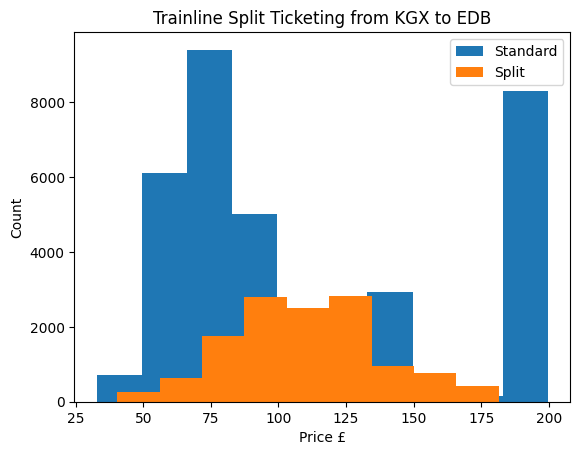

In [11]:
# price distribution from ORIGIN to DESTINATIONS
plt.hist(get_journeys_between(ticket_data, ORIGIN, DESTINATION).get_column("cheapest_standard_class"), label="Standard")
plt.hist(get_journeys_between(ticket_data, ORIGIN, DESTINATION).get_column("cheapest_standard_class_split"), label="Split")
plt.xlabel("Price £")
plt.ylabel("Count")
plt.title(f"Trainline Split Ticketing from {ORIGIN} to {DESTINATION}")
plt.legend()
trainline_split = get_journeys_between(ticket_data, ORIGIN, DESTINATION).get_column("cheapest_standard_class_split")
print(f"Trainline Split Ticketing: {trainline_split.mean()} mean")
plt.savefig(f"trainline_split_{ORIGIN}_{DESTINATION}.pdf")

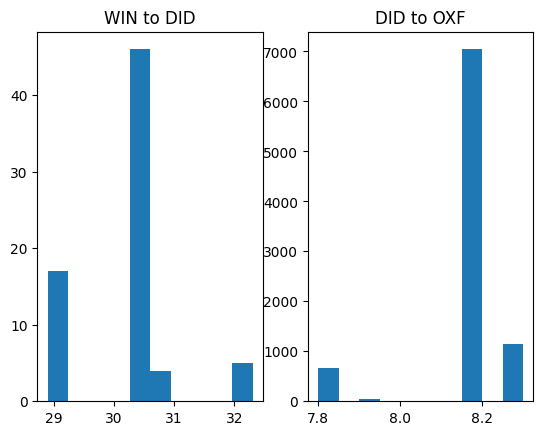

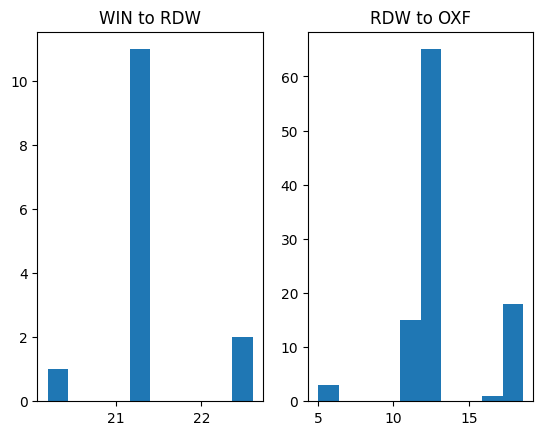

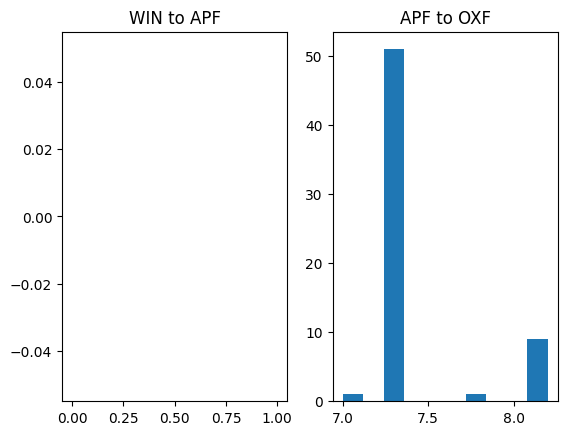

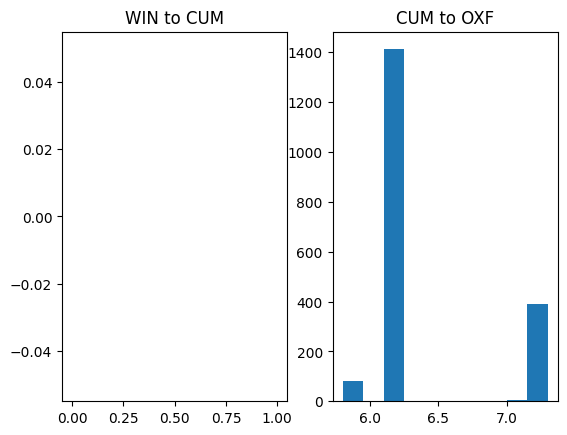

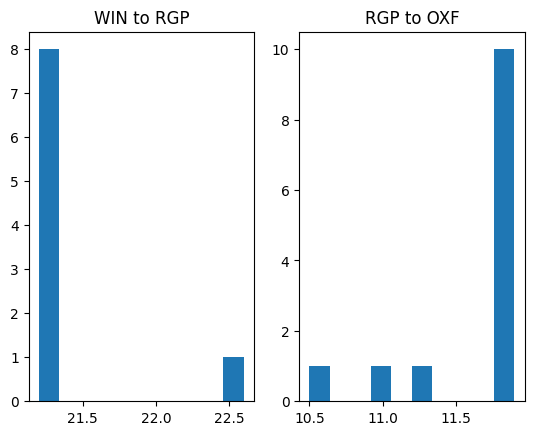

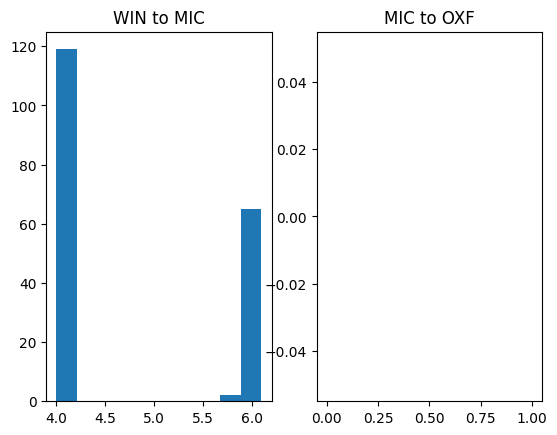

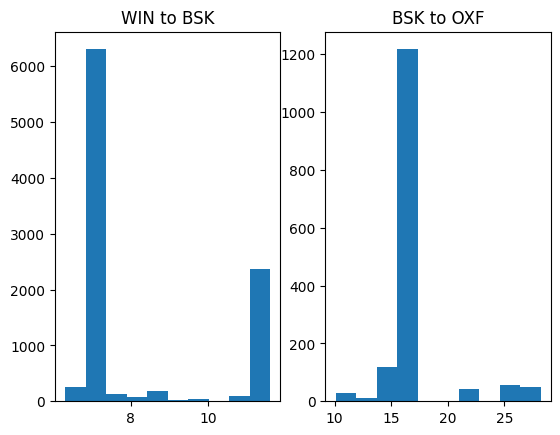

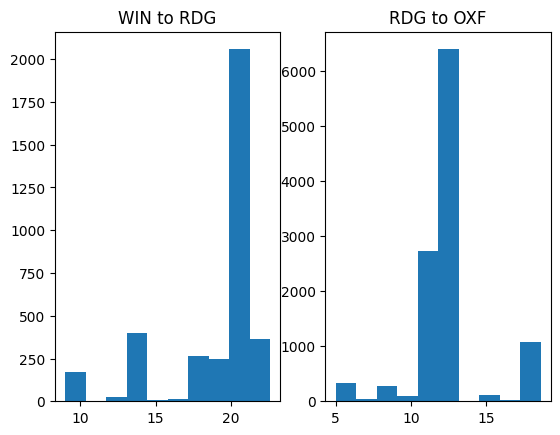

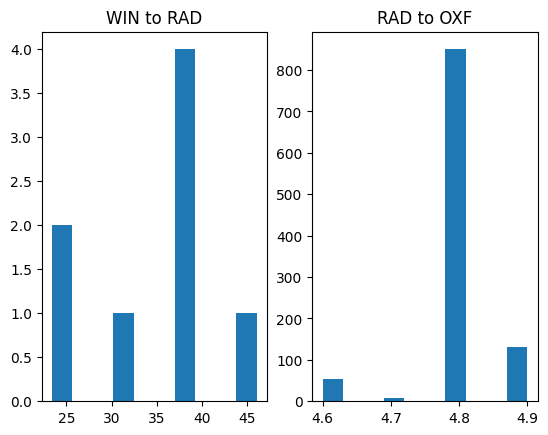

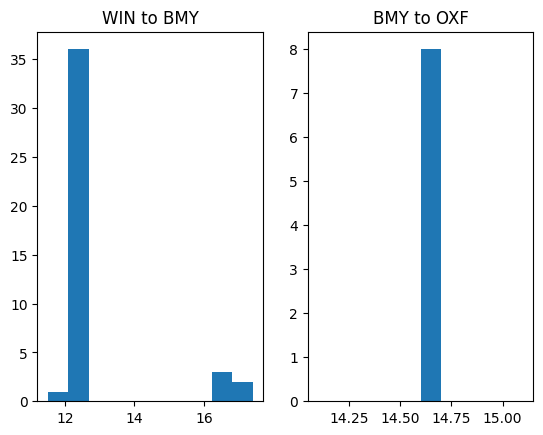

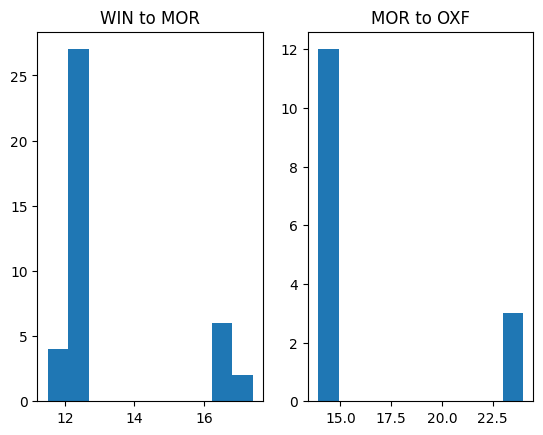

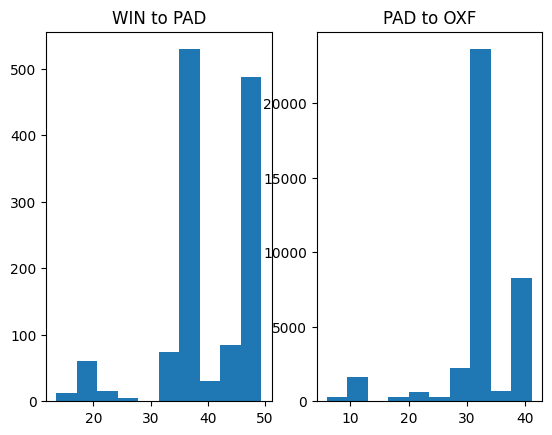

In [12]:
for station in intermediate:
    if station in [ORIGIN, DESTINATION]:
        continue
    fig, axs = plt.subplots(ncols=2)
    a = get_journeys_between(ticket_data, ORIGIN, station).get_column("cheapest_standard_class")
    b = get_journeys_between(ticket_data, station, DESTINATION).get_column("cheapest_standard_class")
    axs[0].hist(a)
    axs[0].set_title(f"{ORIGIN} to {station}")
    axs[1].hist(b)
    axs[1].set_title(f"{station} to {DESTINATION}")

In [15]:
filtered = get_journeys_between(ticket_data, ORIGIN, DESTINATION).filter(
    pl.col("used_split_points").str.len_chars() > 0
)
split_points = filtered.get_column("used_split_points")
split_points.unique()

used_split_points
str
"""YRK"""
"""SUN"""
"""NTR"""
"""PBO"""
"""BWK"""
…
"""CAR"""
"""NNG"""
"""CRE"""


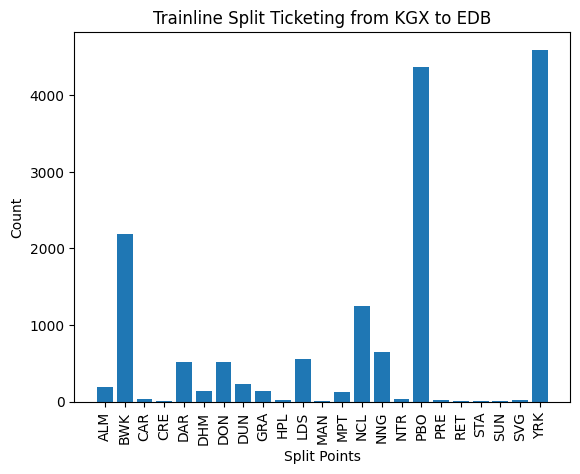

In [16]:
points, counts = np.unique(split_points, return_counts=True)
mask = counts > 1
plt.bar(points[mask], counts[mask])
plt.xticks(rotation=90)
plt.xlabel("Split Points")
plt.ylabel("Count")
plt.title(f"Trainline Split Ticketing from {ORIGIN} to {DESTINATION}")
plt.savefig(f"split_points_{ORIGIN}_{DESTINATION}.pdf")


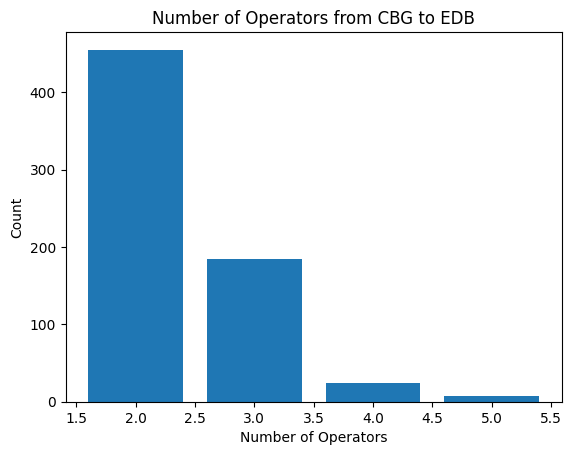

In [52]:
n_operators = filtered.get_column("vendors").list.len()

plt.bar(*np.unique(n_operators, return_counts=True))
plt.xlabel("Number of Operators")
plt.ylabel("Count")
plt.title(f"Number of Operators from {ORIGIN} to {DESTINATION}")
plt.savefig(f"n_operators_{ORIGIN}_{DESTINATION}.pdf")


In [17]:
inter = get_journeys_between(ticket_data, "KGX", "EDB")[1]["intermediate_points"].to_list()[0].split(",")
inter

['KGX', 'PBO', 'NNG', 'DON', 'YRK', 'NTR', 'DAR', 'DHM', 'NCL', 'EDB']

In [18]:
all_posible_routes = []
for i in range(len(inter)):
    for j in range(i+1, len(inter)):
        all_posible_routes.append(",".join(inter[i:j+1]))
all_posible_routes

['KGX,PBO',
 'KGX,PBO,NNG',
 'KGX,PBO,NNG,DON',
 'KGX,PBO,NNG,DON,YRK',
 'KGX,PBO,NNG,DON,YRK,NTR',
 'KGX,PBO,NNG,DON,YRK,NTR,DAR',
 'KGX,PBO,NNG,DON,YRK,NTR,DAR,DHM',
 'KGX,PBO,NNG,DON,YRK,NTR,DAR,DHM,NCL',
 'KGX,PBO,NNG,DON,YRK,NTR,DAR,DHM,NCL,EDB',
 'PBO,NNG',
 'PBO,NNG,DON',
 'PBO,NNG,DON,YRK',
 'PBO,NNG,DON,YRK,NTR',
 'PBO,NNG,DON,YRK,NTR,DAR',
 'PBO,NNG,DON,YRK,NTR,DAR,DHM',
 'PBO,NNG,DON,YRK,NTR,DAR,DHM,NCL',
 'PBO,NNG,DON,YRK,NTR,DAR,DHM,NCL,EDB',
 'NNG,DON',
 'NNG,DON,YRK',
 'NNG,DON,YRK,NTR',
 'NNG,DON,YRK,NTR,DAR',
 'NNG,DON,YRK,NTR,DAR,DHM',
 'NNG,DON,YRK,NTR,DAR,DHM,NCL',
 'NNG,DON,YRK,NTR,DAR,DHM,NCL,EDB',
 'DON,YRK',
 'DON,YRK,NTR',
 'DON,YRK,NTR,DAR',
 'DON,YRK,NTR,DAR,DHM',
 'DON,YRK,NTR,DAR,DHM,NCL',
 'DON,YRK,NTR,DAR,DHM,NCL,EDB',
 'YRK,NTR',
 'YRK,NTR,DAR',
 'YRK,NTR,DAR,DHM',
 'YRK,NTR,DAR,DHM,NCL',
 'YRK,NTR,DAR,DHM,NCL,EDB',
 'NTR,DAR',
 'NTR,DAR,DHM',
 'NTR,DAR,DHM,NCL',
 'NTR,DAR,DHM,NCL,EDB',
 'DAR,DHM',
 'DAR,DHM,NCL',
 'DAR,DHM,NCL,EDB',
 'DHM,NCL',
 'DHM,NC